In [1]:
# ===============================
# 0) Imports & Setup
# ===============================
import os, gc, json, math, random, re, warnings
from pathlib import Path
from collections import defaultdict
from dataclasses import dataclass

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge

from skimage import color
from skimage.feature import hog

from PIL import Image
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42)

In [2]:
# ===============================
# 1) Config
# ===============================
@dataclass
class CFG:
    DATA_ROOT: str = "/kaggle/input/yelp-complete-open-dataset-2024"
    MAX_REVIEWS: int = 1_000_000
    MAX_USERS: int = 200_000
    MAX_ITEMS: int = 200_000
    MIN_USER_REVIEWS: int = 5
    MIN_ITEM_REVIEWS: int = 5
    IMG_LIMIT: int = 25_000
    IMG_SIZE: tuple = (128, 128)
    HOG_PIXELS_PER_CELL: tuple = (16, 16)
    HOG_CELLS_PER_BLOCK: tuple = (2, 2)
    HOG_ORIENTATIONS: int = 9
    COLOR_HIST_BINS: int = 32
    TEST_SIZE: float = 0.2
    VAL_SIZE: float = 0.1
    TOP_K: int = 10
    HIDDEN: tuple = (256, 128)
    EPOCHS: int = 15
    BATCH_SIZE: int = 2048
    # Re-ranking config (for Hybrid)
    RERANK: dict = None

CFG = CFG()
if CFG.RERANK is None:
    CFG.RERANK = {
        "enabled": True,
        "alpha": 0.65,     # relevance weight (1-alpha = diversity)
        "beta_pop": 0.10,  # popularity penalty (0=off)
        "feat": "both",   # similarity features: "vis" | "num" | "both"
    }


In [3]:
# ===============================
# 2) Utility functions
# ===============================

def read_json_lines(path, max_rows=None):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if max_rows is not None and i >= max_rows: break
            rows.append(json.loads(line))
    return pd.DataFrame(rows)


def _find_photos_root(base: Path) -> Path:
    candidates = [base/"yelp_photos"/"photos"/"models", base/"yelp_photos"/"photos", base/"photos"/"models", base/"photos"]
    for c in candidates:
        if c.exists():
            jpgs = list(c.glob("*.jpg"))
            if len(jpgs) > 100: return c
    best, best_count = None, 0
    for p in base.rglob("*"):
        if p.is_dir():
            cnt = len(list(p.glob("*.jpg")))
            if cnt > best_count:
                best, best_count = p, cnt
    return best if best is not None else base


In [4]:
# ===============================
# 3) Load Yelp data
# ===============================
root = Path(CFG.DATA_ROOT)
rev_path = root/"yelp_dataset"/"yelp_academic_dataset_review.json"
usr_path = root/"yelp_dataset"/"yelp_academic_dataset_user.json"
biz_path = root/"yelp_dataset"/"yelp_academic_dataset_business.json"
photos_json = root/"yelp_photos"/"photos.json"

print("Loading reviews...")
reviews = read_json_lines(rev_path, max_rows=CFG.MAX_REVIEWS)[["review_id","user_id","business_id","stars","text","date"]]
print("reviews:", reviews.shape)

print("Loading users...")
users = read_json_lines(usr_path, max_rows=CFG.MAX_USERS)[["user_id","review_count","yelping_since","useful","funny","cool","friends"]].fillna({"friends":""})
print("users:", users.shape)

print("Loading business...")
biz = read_json_lines(biz_path, max_rows=CFG.MAX_ITEMS)[["business_id","name","city","state","categories"]]
print("business:", biz.shape)

print("Loading photos meta...")
try:
    photos_raw = read_json_lines(photos_json)
    if photos_raw.empty: raise ValueError("empty jsonl")
except Exception:
    with open(photos_json, 'r', encoding='utf-8') as f:
        data = json.load(f)
    photos_raw = pd.DataFrame(data)
photos = photos_raw[["photo_id","business_id"]].dropna()
photos_root = _find_photos_root(root)
print("Detected photos_root:", photos_root)


Loading reviews...
reviews: (1000000, 6)
Loading users...
users: (200000, 7)
Loading business...
business: (150346, 5)
Loading photos meta...
Detected photos_root: /kaggle/input/yelp-complete-open-dataset-2024/yelp_photos/photos


In [5]:
# ===============================
# 4) Basic filtering
# ===============================
user_counts = reviews["user_id"].value_counts()
item_counts = reviews["business_id"].value_counts()
valid_users = set(user_counts[user_counts >= CFG.MIN_USER_REVIEWS].index)
valid_items = set(item_counts[item_counts >= CFG.MIN_ITEM_REVIEWS].index)
reviews = reviews[reviews.user_id.isin(valid_users) & reviews.business_id.isin(valid_items)].copy()
users = users[users.user_id.isin(valid_users)].copy()
biz = biz[biz.business_id.isin(valid_items)].copy()
print("filtered reviews:", reviews.shape)

filtered reviews: (304872, 6)


In [6]:
 #===============================
# 5) Sentiment (offline, lightweight)
# ===============================
_POS = set(" good great excellent amazing awesome fantastic love loved like liked enjoyable perfect nice wonderful satisfied recommend best outstanding ".split())
_NEG = set(" bad terrible awful worst poor hate hated dislike disliked boring disappointing broken slow dirty rude expensive regret not never ".split())
EMOJI_POS = {":)", ":D", "👍", "❤️", "😍", "🥰", "🤩"}
EMOJI_NEG = {":(", "😡", "👎", "😞", "😢", "😭"}
_punct_exclaim = re.compile(r"!+")
_alpha = re.compile(r"[^a-z]+")

def sentiment_score(text: str) -> float:
    if not isinstance(text, str) or not text: return 0.0
    txt = text.lower(); words = _alpha.sub(" ", txt).split()
    pos = sum(1 for w in words if w in _POS); neg = sum(1 for w in words if w in _NEG)
    ex = len(_punct_exclaim.findall(text))
    emo_pos = sum(text.count(e) for e in EMOJI_POS); emo_neg = sum(text.count(e) for e in EMOJI_NEG)
    norm = max(1, len(words))
    score = (pos - neg + 0.5*ex + emo_pos - emo_neg) / math.sqrt(norm)
    return float(np.tanh(score))

print("Computing review sentiment...")
reviews["sentim"] = reviews["text"].map(sentiment_score)
ui_sent = reviews.groupby(["user_id","business_id"]).agg(r=("stars","mean"), s_mean=("sentim","mean"), s_max=("sentim","max"), s_min=("sentim","min"), n=("review_id","count")).reset_index()


Computing review sentiment...


In [7]:
# ===============================
# 6) Trust graph (friends/co-review)
# ===============================
print("Building trust graph...")
friend_edges = []
if "friends" in users.columns:
    for _, row in users.iterrows():
        uid = row.user_id; friends = str(row.friends)
        if friends and friends != 'None':
            for f in friends.split(", "):
                if f: friend_edges.append((uid, f))
friend_edges = pd.DataFrame(friend_edges, columns=["u","v"]) if friend_edges else pd.DataFrame(columns=["u","v"])

if len(friend_edges) == 0:
    print("Friends missing — using implicit trust via co-review similarity")
    pivot = ui_sent.pivot_table(index="user_id", columns="business_id", values="r", fill_value=0.0)
    sim = cosine_similarity(pivot)
    sim_df = pd.DataFrame(sim, index=pivot.index, columns=pivot.index)
    edges = []
    for u in sim_df.index:
        topv = sim_df.loc[u].drop(u).nlargest(10)
        edges += [(u, v) for v in topv.index]
    friend_edges = pd.DataFrame(edges, columns=["u","v"])

users_idx = {u:i for i,u in enumerate(users.user_id.values)}
adj = {u:set() for u in users_idx.keys()}
for u,v in friend_edges.itertuples(index=False):
    if u in users_idx and v in users_idx:
        adj[u].add(v); adj[v].add(u)

trust_deg = {u: len(adj[u]) for u in users_idx.keys()}
trust_2hop = {}
for u in users_idx.keys():
    two = set();
    for v in adj[u]: two |= adj[v]
    two.discard(u); trust_2hop[u] = len(two)

num_users = max(1, len(users_idx))
pr = {u: 1.0/num_users for u in users_idx.keys()}
for _ in range(10):
    new_pr = {u: 0.15/num_users for u in users_idx.keys()}
    for u in users_idx.keys():
        if len(adj[u]) == 0: continue
        share = 0.85 * pr[u] / len(adj[u])
        for v in adj[u]: new_pr[v] += share
    pr = new_pr

trust_df = pd.DataFrame({"user_id": list(users_idx.keys()), "trust_deg": [trust_deg[u] for u in users_idx.keys()], "trust_2hop": [trust_2hop[u] for u in users_idx.keys()], "trust_pr": [pr[u] for u in users_idx.keys()]})


Building trust graph...


In [8]:
# ===============================
# 7) Visual features (fast)
# ===============================
print("Indexing item photos (fast pre-scan)...")
EXTS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")
photos_root = _find_photos_root(root)
id2path = {}
for ext in EXTS:
    for p in photos_root.glob(f"*{ext}"):
        id2path[p.stem] = p
print(f"Indexed {len(id2path):,} images @ {photos_root}")

photo_map = photos.groupby("business_id")["photo_id"].apply(list)
items_with_photo = [bid for bid, plist in photo_map.items() if len(plist)>0][:CFG.IMG_LIMIT]


def image_to_feature(img_path: Path):
    try:
        with Image.open(img_path) as im:
            im = im.convert("RGB"); im = im.resize(CFG.IMG_SIZE, resample=Image.BILINEAR)
            arr = np.asarray(im) / 255.0
        hsv = color.rgb2hsv(arr)
        hist_h = np.histogram(hsv[...,0], bins=CFG.COLOR_HIST_BINS, range=(0,1), density=True)[0]
        hist_s = np.histogram(hsv[...,1], bins=CFG.COLOR_HIST_BINS, range=(0,1), density=True)[0]
        hist_v = np.histogram(hsv[...,2], bins=CFG.COLOR_HIST_BINS, range=(0,1), density=True)[0]
        hog_feat = hog(color.rgb2gray(arr), pixels_per_cell=CFG.HOG_PIXELS_PER_CELL, cells_per_block=CFG.HOG_CELLS_PER_BLOCK, orientations=CFG.HOG_ORIENTATIONS, feature_vector=True)
        return np.concatenate([hist_h, hist_s, hist_v, hog_feat]).astype("float32")
    except Exception:
        return None

_feature_cache = {}

def featurize_business(bid):
    plist = photo_map.get(bid, [])
    feats = []
    for pid in plist[:2]:
        p = id2path.get(str(pid))
        if p is None: continue
        if p in _feature_cache: f = _feature_cache[p]
        else: f = image_to_feature(p); _feature_cache[p] = f
        if f is not None: feats.append(f)
    if len(feats): return (bid, np.mean(np.stack(feats, axis=0), axis=0))
    return None

print("Extracting visual features with multiprocessing...")
vis_rows = []
with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
    futures = {ex.submit(featurize_business, bid): bid for bid in items_with_photo}
    for fut in as_completed(futures):
        res = fut.result()
        if res is not None: vis_rows.append(res)

if len(vis_rows) == 0:
    print("No usable images — creating zero visual features")
    cells_y = CFG.IMG_SIZE[0] // CFG.HOG_PIXELS_PER_CELL[0]
    cells_x = CFG.IMG_SIZE[1] // CFG.HOG_PIXELS_PER_CELL[1]
    blocks_y = max(1, cells_y - 1); blocks_x = max(1, cells_x - 1)
    hog_dim = (blocks_y * blocks_x * CFG.HOG_CELLS_PER_BLOCK[0] * CFG.HOG_CELLS_PER_BLOCK[1] * CFG.HOG_ORIENTATIONS)
    vis_dim = 3*CFG.COLOR_HIST_BINS + hog_dim
    vis_df = pd.DataFrame({"business_id": biz.business_id.values, "vis": [np.zeros(vis_dim, dtype=np.float32)]*len(biz)})
else:
    vis_df = pd.DataFrame(vis_rows, columns=["business_id","vis"])


Indexing item photos (fast pre-scan)...
Indexed 200,098 images @ /kaggle/input/yelp-complete-open-dataset-2024/yelp_photos/photos
Extracting visual features with multiprocessing...


In [9]:
# ===============================
# 8) Feature tables + robust vis zero-fill
# ===============================
print("Aggregating user/item features...")
u_sent = reviews.groupby("user_id").agg(u_sent_mean=("sentim","mean"), u_sent_std=("sentim","std"), u_rev_n=("review_id","count"), u_star_mean=("stars","mean")).reset_index().fillna(0.0)

i_sent = reviews.groupby("business_id").agg(i_sent_mean=("sentim","mean"), i_sent_std=("sentim","std"), i_rev_n=("review_id","count"), i_star_mean=("stars","mean")).reset_index().fillna(0.0)

u_feat = u_sent.merge(trust_df, on="user_id", how="left").fillna(0.0)
i_feat = i_sent.merge(vis_df, on="business_id", how="left")

# robust vis handling
sample = i_feat["vis"].dropna()
if len(sample): VIS_DIM = int(len(sample.iloc[0]))
else:
    cells_y = CFG.IMG_SIZE[0] // CFG.HOG_PIXELS_PER_CELL[0]
    cells_x = CFG.IMG_SIZE[1] // CFG.HOG_PIXELS_PER_CELL[1]
    blocks_y = max(1, cells_y - 1); blocks_x = max(1, cells_x - 1)
    hog_dim = (blocks_y * blocks_x * CFG.HOG_CELLS_PER_BLOCK[0] * CFG.HOG_CELLS_PER_BLOCK[1] * CFG.HOG_ORIENTATIONS)
    VIS_DIM = 3*CFG.COLOR_HIST_BINS + hog_dim

def _to_vis_array(v, dim=VIS_DIM):
    if isinstance(v, (np.ndarray, list)):
        arr = np.asarray(v, dtype=np.float32).ravel()
        if arr.size < dim: return np.pad(arr, (0, dim-arr.size), mode='constant')
        return arr[:dim]
    return np.zeros(dim, dtype=np.float32)

i_feat["vis"] = i_feat["vis"].apply(_to_vis_array)


Aggregating user/item features...


In [10]:
# ===============================
# 9) Train/Val/Test (cold-start aware)
# ===============================
print("Splitting train/val/test with cold-start emphasis...")
user_freq = u_feat.set_index("user_id")["u_rev_n"]
item_freq = i_feat.set_index("business_id")["i_rev_n"]

cold_users = set(user_freq.nsmallest(int(0.2*len(user_freq))).index)
cold_items = set(item_freq.nsmallest(int(0.2*len(item_freq))).index)

ui = ui_sent.copy()
ui["is_cold_user"] = ui.user_id.isin(cold_users).astype(int)
ui["is_cold_item"] = ui.business_id.isin(cold_items).astype(int)

train_ui, test_ui = train_test_split(ui, test_size=CFG.TEST_SIZE, random_state=42, stratify=ui[["is_cold_user","is_cold_item"]])
train_ui, val_ui  = train_test_split(train_ui, test_size=CFG.VAL_SIZE, random_state=42, stratify=train_ui[["is_cold_user","is_cold_item"]])
print("train/val/test sizes:", len(train_ui), len(val_ui), len(test_ui))


Splitting train/val/test with cold-start emphasis...
train/val/test sizes: 206171 22908 57270


In [11]:
# ===============================
# 10) Vectorized (u,i) feature build
# ===============================
print("Building (u,i) feature matrices (vectorized)...")

u_map = u_feat.set_index("user_id")
i_map = i_feat.set_index("business_id")

u_num_cols = ["u_sent_mean","u_sent_std","u_rev_n","u_star_mean","trust_deg","trust_2hop","trust_pr"]
i_num_cols = ["i_sent_mean","i_sent_std","i_rev_n","i_star_mean"]

scaler_u = StandardScaler().fit(u_map[u_num_cols])
scaler_i = StandardScaler().fit(i_map[i_num_cols])

u_scaled = pd.DataFrame(scaler_u.transform(u_map[u_num_cols]), index=u_map.index, columns=u_num_cols)
i_scaled = pd.DataFrame(scaler_i.transform(i_map[i_num_cols]), index=i_map.index, columns=i_num_cols)

bid2vis = i_map["vis"].to_dict()


def make_features_fast(df_ui: pd.DataFrame):
    u_blk = df_ui[["user_id"]].merge(u_scaled.reset_index(), on="user_id", how="left")[u_num_cols].to_numpy(dtype=np.float32)
    i_blk = df_ui[["business_id"]].merge(i_scaled.reset_index(), on="business_id", how="left")[i_num_cols].to_numpy(dtype=np.float32)
    vis_blk = np.vstack([bid2vis.get(b) for b in df_ui["business_id"].values]).astype(np.float32)
    ui_extra = df_ui[["s_mean","s_max","s_min","n","is_cold_user","is_cold_item"]].to_numpy(dtype=np.float32)
    X = np.hstack([u_blk, i_blk, vis_blk, ui_extra]).astype(np.float32)
    y = df_ui["r"].to_numpy(dtype=np.float32)
    return X, y

X_train, y_train = make_features_fast(train_ui)
X_val,   y_val   = make_features_fast(val_ui)
X_test,  y_test  = make_features_fast(test_ui)
print("Feature dims:", X_train.shape)

Building (u,i) feature matrices (vectorized)...
Feature dims: (206171, 1877)


In [12]:
# ===============================
# 11) Helpers: candidates, truth, metrics
# ===============================
K = CFG.TOP_K

# ground-truth relevant items (rating >= 4)
def truth_from_df(test_df):
    by_user_truth = defaultdict(set)
    for row in test_df.itertuples(index=False):
        if row.r >= 4.0:
            by_user_truth[row.user_id].add(row.business_id)
    return by_user_truth
truth_by_user = truth_from_df(test_ui)

# candidates per user
cands_by_user = defaultdict(list)
for row in test_ui.itertuples(index=False):
    cands_by_user[row.user_id].append(row.business_id)

# item feature for diversity similarity

def item_feat_for_div(bids, mode="both"):
    if mode == "vis":
        return np.vstack([i_map.loc[b, "vis"] for b in bids]).astype(np.float32)
    elif mode == "num":
        return i_map.loc[bids, i_num_cols].to_numpy(dtype=np.float32)
    else:
        A = i_map.loc[bids, i_num_cols].to_numpy(dtype=np.float32)
        B = np.vstack([i_map.loc[b, "vis"] for b in bids]).astype(np.float32)
        return np.hstack([A,B]).astype(np.float32)


def eval_topk(scores_by_user, truth_by_user, feat_builder=lambda bids: item_feat_for_div(bids, "num")):
    user_prec, user_rec, user_div = [], [], []
    all_recommended = set()
    for u, scored in scores_by_user.items():
        if not scored: continue
        scored = sorted(scored, key=lambda x: -x[1])[:K]
        rec_items = [b for (b,_) in scored]
        all_recommended.update(rec_items)
        rel = truth_by_user.get(u, set())
        hits = len([b for b in rec_items if b in rel])
        user_prec.append(hits / K)
        user_rec.append(hits / max(1, len(rel)))
        if len(rec_items) > 1:
            V = feat_builder(rec_items)
            S = cosine_similarity(V)
            triu = np.triu_indices_from(S, k=1)
            div = float(np.mean(1.0 - S[triu]))
        else:
            div = 0.0
        user_div.append(div)
    return {
        "Precision@K": float(np.mean(user_prec)) if user_prec else 0.0,
        "Recall@K": float(np.mean(user_rec)) if user_rec else 0.0,
        "Coverage": len(all_recommended) / max(1, len(i_map)),
        "Diversity": float(np.mean(user_div)) if user_div else 0.0,
    }

In [13]:
# ===============================
# 12) Baselines
# ===============================
# 12.1 CF (MF-SGD)
print("Training CF (MF-SGD)...")
uid2idx = {u:i for i,u in enumerate(u_map.index)}
bid2idx = {b:i for i,b in enumerate(i_map.index)}
Udim, Idim, D = len(uid2idx), len(bid2idx), 32
P = 0.1*np.random.randn(Udim, D).astype(np.float32)
Q = 0.1*np.random.randn(Idim, D).astype(np.float32)
bu = np.zeros(Udim, dtype=np.float32); bi = np.zeros(Idim, dtype=np.float32)
mu = float(train_ui["r"].mean())

def sgd_epoch(df, lr=0.015, reg=1e-4):
    for row in df.itertuples(index=False):
        ui = uid2idx.get(row.user_id, None); ii = bid2idx.get(row.business_id, None)
        if ui is None or ii is None: continue
        pred = mu + bu[ui] + bi[ii] + P[ui] @ Q[ii]
        err = row.r - pred
        bu[ui] += lr*(err - reg*bu[ui]); bi[ii] += lr*(err - reg*bi[ii])
        p_u = P[ui].copy(); q_i = Q[ii].copy()
        P[ui] += lr*(err*q_i - reg*p_u)
        Q[ii] += lr*(err*p_u - reg*q_i)

for ep in range(8):
    sgd_epoch(train_ui.sample(frac=1.0, random_state=42+ep))

def cf_score(u, b):
    ui = uid2idx.get(u, None); ii = bid2idx.get(b, None)
    if ui is None or ii is None: return mu
    return float(mu + bu[ui] + bi[ii] + P[ui] @ Q[ii])

scores_cf = {u: [(b, cf_score(u,b)) for b in bids] for u,bids in cands_by_user.items()}
metrics_cf = eval_topk(scores_cf, truth_by_user, lambda bids: item_feat_for_div(bids, "num"))

# 12.2 CB (Content-Based)
print("Evaluating CB (content profile)...")
ItemC = np.hstack([
    i_map[i_num_cols].to_numpy(dtype=np.float32),
    np.vstack(i_map["vis"].values).astype(np.float32)
]).astype(np.float32)
_blist = i_map.index.tolist(); _bpos = {b:i for i,b in enumerate(_blist)}

pos_by_user = defaultdict(list)
for row in train_ui.itertuples(index=False):
    if row.r >= 4.0: pos_by_user[row.user_id].append(row.business_id)

user_prof = {}
for u, liked in pos_by_user.items():
    idxs = [_bpos[b] for b in liked if b in _bpos]
    user_prof[u] = ItemC[idxs].mean(axis=0) if idxs else ItemC.mean(axis=0)

def cb_score(u,b):
    if u not in user_prof: return 0.0
    v = user_prof[u]; w = ItemC[_bpos[b]]
    denom = (np.linalg.norm(v)+1e-8)*(np.linalg.norm(w)+1e-8)
    return float(np.dot(v,w)/denom)

scores_cb = {u: [(b, cb_score(u,b)) for b in bids] for u,bids in cands_by_user.items()}
metrics_cb = eval_topk(scores_cb, truth_by_user, lambda bids: item_feat_for_div(bids, "both"))

# 12.3 TrustMF-lite
print("Training TrustMF-lite...")
friends = {u:list(adj.get(u,[])) for u in u_map.index}
P_t = 0.1*np.random.randn(Udim, D).astype(np.float32); Q_t = Q.copy()
bu_t = np.zeros(Udim, dtype=np.float32); bi_t = np.zeros(Idim, dtype=np.float32)
mu_t = mu

def sgd_epoch_trust(df, lr=0.012, reg=1e-4, reg_trust=8e-4):
    for row in df.itertuples(index=False):
        ui = uid2idx.get(row.user_id, None); ii = bid2idx.get(row.business_id, None)
        if ui is None or ii is None: continue
        pred = mu_t + bu_t[ui] + bi_t[ii] + P_t[ui] @ Q_t[ii]
        err = row.r - pred
        bu_t[ui] += lr*(err - reg*bu_t[ui]); bi_t[ii] += lr*(err - reg*bi_t[ii])
        p_u = P_t[ui].copy(); q_i = Q_t[ii].copy()
        P_t[ui] += lr*(err*q_i - reg*p_u); Q_t[ii] += lr*(err*p_u - reg*q_i)
        nbrs = friends.get(row.user_id, [])
        if nbrs:
            idxs = [uid2idx[n] for n in nbrs if n in uid2idx]
            if idxs:
                mean_n = P_t[idxs].mean(axis=0)
                P_t[ui] += - lr*reg_trust*(P_t[ui] - mean_n)

for ep in range(8):
    sgd_epoch_trust(train_ui.sample(frac=1.0, random_state=123+ep))

def trustmf_score(u,b):
    ui = uid2idx.get(u, None); ii = bid2idx.get(b, None)
    if ui is None or ii is None: return mu_t
    return float(mu_t + bu_t[ui] + bi_t[ii] + P_t[ui] @ Q_t[ii])

scores_trust = {u: [(b, trustmf_score(u,b)) for b in bids] for u,bids in cands_by_user.items()}
metrics_trust = eval_topk(scores_trust, truth_by_user, lambda bids: item_feat_for_div(bids, "num"))

# 12.4 VBPR-lite
print("Training VBPR-lite...")
Vdim = len(i_map.iloc[0].vis)
U_vis = 0.1*np.random.randn(Udim, 16).astype(np.float32)
E = 0.1*np.random.randn(16, Vdim).astype(np.float32)
P_v = 0.1*np.random.randn(Udim, D).astype(np.float32)
Q_v = 0.1*np.random.randn(Idim, D).astype(np.float32)
bu_v = np.zeros(Udim, dtype=np.float32); bi_v = np.zeros(Idim, dtype=np.float32)
mu_v = mu

def sgd_epoch_vbpr(df, lr=0.01, reg=1e-4, regE=2e-5):
    for row in df.itertuples(index=False):
        ui = uid2idx.get(row.user_id, None); ii = bid2idx.get(row.business_id, None)
        if ui is None or ii is None: continue
        v_i = i_map.iloc[ii].vis; Ev = E @ v_i
        pred = mu_v + bu_v[ui] + bi_v[ii] + P_v[ui] @ Q_v[ii] + U_vis[ui] @ Ev
        err = row.r - pred
        bu_v[ui] += lr*(err - reg*bu_v[ui]); bi_v[ii] += lr*(err - reg*bi_v[ii])
        p_u = P_v[ui].copy(); q_i = Q_v[ii].copy(); u_vis = U_vis[ui].copy()
        P_v[ui] += lr*(err*q_i - reg*p_u); Q_v[ii] += lr*(err*p_u - reg*q_i)
        U_vis[ui] += lr*(err*Ev - reg*u_vis)
        E[:] += lr*(np.outer(U_vis[ui], v_i)*err - regE*E)

for ep in range(6):
    sgd_epoch_vbpr(train_ui.sample(frac=1.0, random_state=77+ep))

def vbpr_score(u,b):
    ui = uid2idx.get(u, None); ii = bid2idx.get(b, None)
    if ui is None or ii is None: return mu_v
    v_i = i_map.iloc[ii].vis; Ev = E @ v_i
    return float(mu_v + bu_v[ui] + bi_v[ii] + P_v[ui] @ Q_v[ii] + U_vis[ui] @ Ev)

scores_vbpr = {u: [(b, vbpr_score(u,b)) for b in bids] for u,bids in cands_by_user.items()}
metrics_vbpr = eval_topk(scores_vbpr, truth_by_user, lambda bids: item_feat_for_div(bids, "both"))

# 12.5 Sentiment-Aware (Ridge)
print("Training Sentiment-Aware (Ridge)...")
sent_u_cols = ["u_sent_mean","u_sent_std"]
sent_i_cols = ["i_sent_mean","i_sent_std"]

def make_sent_features(df_ui):
    u_blk = df_ui[["user_id"]].merge(u_map[sent_u_cols].reset_index(), on="user_id", how="left")[sent_u_cols].to_numpy(dtype=np.float32)
    i_blk = df_ui[["business_id"]].merge(i_map[sent_i_cols].reset_index(), on="business_id", how="left")[sent_i_cols].to_numpy(dtype=np.float32)
    ui_extra = df_ui[["s_mean","s_max","s_min","n"]].to_numpy(dtype=np.float32)
    X = np.hstack([u_blk, i_blk, ui_extra]).astype(np.float32)
    y = df_ui["r"].to_numpy(dtype=np.float32)
    return X, y

Xtr_s, ytr_s = make_sent_features(train_ui)
Xva_s, yva_s = make_sent_features(val_ui)
sent_model = Ridge(alpha=1.0).fit(Xtr_s, ytr_s)

scores_sent = {}
for u, bids in cands_by_user.items():
    df = pd.DataFrame({"user_id":[u]*len(bids),"business_id":bids,"r":[0.0]*len(bids),"s_mean":[0.0]*len(bids),"s_max":[0.0]*len(bids),"s_min":[0.0]*len(bids),"n":[1]*len(bids)})
    Xcand,_ = make_sent_features(df)
    s = sent_model.predict(Xcand)
    scores_sent[u] = list(zip(bids, s.astype(float)))
metrics_sent = eval_topk(scores_sent, truth_by_user, lambda bids: item_feat_for_div(bids, "num"))


Training CF (MF-SGD)...
Evaluating CB (content profile)...
Training TrustMF-lite...
Training VBPR-lite...
Training Sentiment-Aware (Ridge)...


In [14]:
# ===============================
# 13) Hybrid (ours) + MMR re-ranking
# ===============================
print("Training Hybrid MLP...")
mlp = MLPRegressor(hidden_layer_sizes=CFG.HIDDEN, activation='relu', solver='adam', max_iter=CFG.EPOCHS, random_state=42, batch_size=CFG.BATCH_SIZE)
mlp.fit(X_train, y_train)
rmse_test = math.sqrt(mean_squared_error(y_test, mlp.predict(X_test)))
mae_test  = mean_absolute_error(y_test, mlp.predict(X_test))
print({"RMSE_test": rmse_test, "MAE_test": mae_test})

ALPHA = float(CFG.RERANK.get("alpha", 0.65)); BETA_POP = float(CFG.RERANK.get("beta_pop", 0.1)); FEAT_MODE = CFG.RERANK.get("feat", "both")

def build_item_features_for_diversity(bids):
    return item_feat_for_div(bids, FEAT_MODE)

def mmr_rerank(items, scores, feat_mat, K=10, alpha=ALPHA):
    N = len(items)
    if N == 0: return []
    S = cosine_similarity(feat_mat)
    sel, rem = [], list(range(N))
    while len(sel) < min(K,N) and rem:
        best_idx, best_val = None, -1e18
        for i in rem:
            rel = float(scores[i]); div = 0.0 if len(sel)==0 else float(np.max(S[i, sel]))
            val = alpha*rel - (1-alpha)*div
            if val > best_val: best_val, best_idx = val, i
        sel.append(best_idx); rem.remove(best_idx)
    return [items[i] for i in sel]

scores_hybrid = {}
for u, bids in cands_by_user.items():
    df = pd.DataFrame({"user_id":[u]*len(bids),"business_id":bids,"r":[0.0]*len(bids),"s_mean":[0.0]*len(bids),"s_max":[0.0]*len(bids),"s_min":[0.0]*len(bids),"n":[1]*len(bids),"is_cold_user":[int(u in cold_users)]*len(bids),"is_cold_item":[0]*len(bids)})
    Xcand,_ = make_features_fast(df)
    s = mlp.predict(Xcand).astype(np.float32)
    if BETA_POP > 0:
        pop = i_map.loc[bids, "i_rev_n"].to_numpy(dtype=np.float32)
        s = s - BETA_POP*np.log1p(pop)
    if CFG.RERANK.get("enabled", True):
        F = build_item_features_for_diversity(bids)
        rec = mmr_rerank(bids, s, F, K=K, alpha=ALPHA)
        idx = {b:i for i,b in enumerate(bids)}
        scores_hybrid[u] = [(b, float(s[idx[b]])) for b in rec]
    else:
        order = np.argsort(-s)[:K]
        scores_hybrid[u] = [(bids[i], float(s[i])) for i in order]

metrics_hybrid = eval_topk(scores_hybrid, truth_by_user, lambda bids: item_feat_for_div(bids, "both"))


Training Hybrid MLP...
{'RMSE_test': 0.7971004092482364, 'MAE_test': 0.60982}


In [15]:
# ===============================
# 14) Summary + Precision–Diversity plot + Bar Charts
# ===============================
results = {
    "CF": metrics_cf,
    "CB": metrics_cb,
    "TrustMF": metrics_trust,
    "VBPR": metrics_vbpr,
    "Sentiment-Aware RS": metrics_sent,
    "Hybrid (ours)": metrics_hybrid,
}

print("=== Baselines vs Hybrid (Top-K) ===")
print(f"{'Method':<22} {'Prec':>8} {'Rec':>8} {'Cov':>8} {'Div':>8}")
for k,v in results.items():
    print(f"{k:<22} {v['Precision@K']:>8.3f} {v['Recall@K']:>8.3f} {v['Coverage']:>8.3f} {v['Diversity']:>8.3f}")



=== Baselines vs Hybrid (Top-K) ===
Method                     Prec      Rec      Cov      Div
CF                        0.167    0.833    0.636    0.035
CB                        0.166    0.832    0.627    0.080
TrustMF                   0.167    0.833    0.636    0.035
VBPR                      0.166    0.832    0.637    0.081
Sentiment-Aware RS        0.167    0.833    0.635    0.035
Hybrid (ours)             0.167    0.833    0.638    0.081


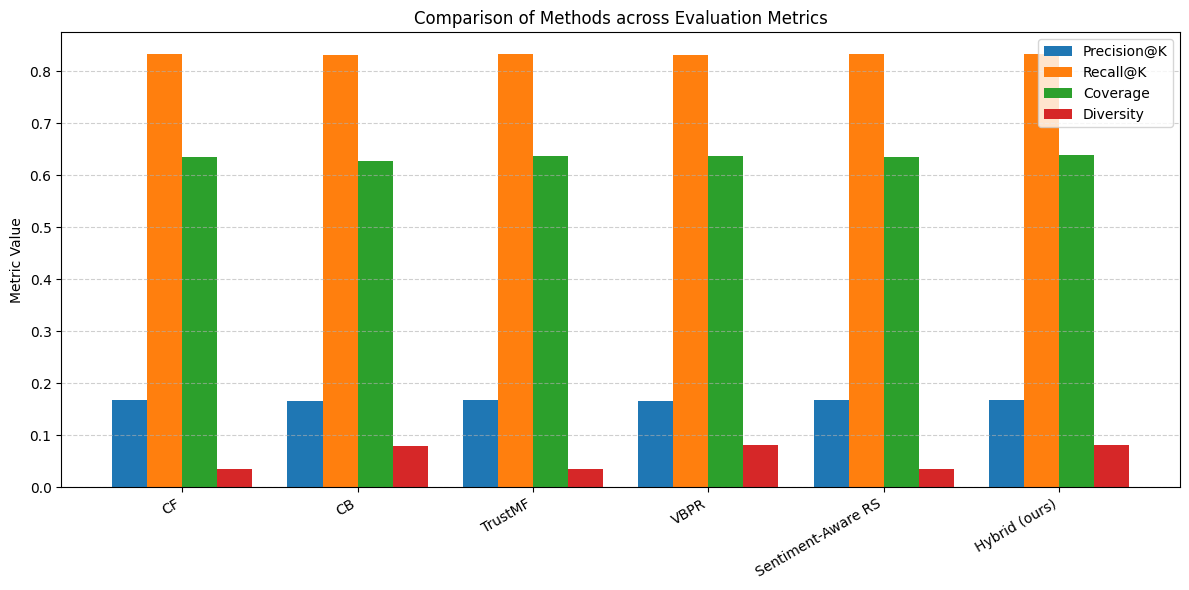

In [16]:
import numpy as np
import matplotlib.pyplot as plt

methods = list(results.keys())
precision = [results[m]["Precision@K"] for m in methods]
recall    = [results[m]["Recall@K"]     for m in methods]
coverage  = [results[m]["Coverage"]     for m in methods]
diversity = [results[m]["Diversity"]    for m in methods]

metrics = {
    "Precision@K": precision,
    "Recall@K": recall,
    "Coverage": coverage,
    "Diversity": diversity
}

x = np.arange(len(methods))  # محل روش‌ها روی محور x
width = 0.2                  # پهنای هر میله

plt.figure(figsize=(12,6))
plt.bar(x - 1.5*width, precision, width, label="Precision@K")
plt.bar(x - 0.5*width, recall,    width, label="Recall@K")
plt.bar(x + 0.5*width, coverage,  width, label="Coverage")
plt.bar(x + 1.5*width, diversity, width, label="Diversity")

plt.xticks(x, methods, rotation=30, ha="right")
plt.ylabel("Metric Value")
plt.title("Comparison of Methods across Evaluation Metrics")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
